In [1]:
import pandas as pd
import pysam
import sys

def read_bed_file(bed_file):
    """Read BED file: chr, pos (1-based), allele1, allele2"""
    df = pd.read_csv(bed_file, sep='\t')
    print(f"Read {len(df)} variants from BED file")
    return df

In [2]:
df = read_bed_file("/oak/stanford/groups/akundaje/anusri/chrombpnet_zenodo_uploads_reformatted/Variant_effect_prediction_all/dsqtls.yoruba.lcls.benchmarking.all.tsv")



Read 28309 variants from BED file


In [3]:
import pybedtools

In [4]:
bed2_path="/mnt/lab_data2/anusri/dsqtls/HG001_GRCh37_1_22_v4.2.1_benchmark.bed"

out_df = df.copy()
out_df["pos0"] = out_df["var.pos_hg19"].astype(int) - 1
bed_like = out_df[["var.chr", "pos0", "var.pos_hg19"]].copy()
bed_like.columns = ["chrom", "start", "end"]
bed_like["start"] = bed_like["start"].astype(int)
bed_like["end"] = bed_like["end"].astype(int)
print(bed_like.head())

bed2 = pd.read_csv(bed2_path, sep='\t', header=None)
#print(bed2.head())
bed2[0] = "chr"+bed2[0].astype(str)
print(bed2.head())
# Build BedTool objects
a_bt = pybedtools.BedTool.from_dataframe(bed_like)
b_bt =  pybedtools.BedTool.from_dataframe(bed2)


# Intersect with -c to count overlaps per A feature; order is preserved
inter = a_bt.intersect(b_bt, c=True)

# Convert to DataFrame and take the last column as the overlap count
inter_df = inter.to_dataframe()
overlap_counts = inter_df.iloc[:, -1].astype(int)

# Append boolean flag to the original DataFrame
out_df["in_bed2"] = overlap_counts > 0


  chrom    start      end
0  chr1   856582   856583
1  chr1   911594   911595
2  chr1  1186501  1186502
3  chr1  1227411  1227412
4  chr1  1590574  1590575
      0       1       2
0  chr1  539856  540256
1  chr1  540273  540420
2  chr1  540592  540727
3  chr1  540829  540920
4  chr1  541022  541106


In [5]:
out_df.shape

(28309, 47)

In [6]:
df.shape

(28309, 45)

In [7]:
sum(out_df["in_bed2"])

25419

In [8]:
out_df.shape

(28309, 47)

In [9]:
df.shape

(28309, 45)

In [10]:
df['in_bed2'] = out_df['in_bed2']

In [11]:
def get_vcf_genotype(vcf, chr_name, pos, qtl_alleles, in_bed2):
    """Get genotype from VCF at specific position"""

    chr_variants = []
    if str(chr_name).startswith('chr'):
        # If chr_name starts with 'chr', also try without 'chr'
        chr_variant = str(chr_name)[3:]
        chr_variants.append(chr_variant)
        chr_variants.append(str(chr_name))
    else:
        # If chr_name doesn't start with 'chr', also try with 'chr'
        chr_variant = str(chr_name)
        chr_variants.append(chr_variant)
        chr_variants.append("chr"+str(chr_name))
        
    # Fetch variants at position (pysam uses 0-based, so pos-1 to pos)
    for record in vcf.fetch(chr_variant, pos-1, pos):
        #print(pos, record.pos)
        if record.pos == pos:  # VCF pos is 1-based
            sample = record.samples[0]  # First sample
            gt = sample.get('GT', None)

            alleles = [record.alleles[i].upper() for i in gt]  # map GT indices to actual bases
            genotype = "/".join(alleles)
            #print(genotype)
            if len(alleles) > 2:
                print(alleles)
            if len(alleles) < 2:
                print(alleles)

                

            if gt is None or gt == (None, None):
                continue

            if alleles[0] == alleles[1]:  # Homozygous
                if (alleles[0] in qtl_alleles) or (alleles[1] in qtl_alleles):
                    category = "Homozygous match"
                else:
                    category = "Homozygous no match"
            else:  # Heterozygous
                if (alleles[0] in qtl_alleles) or (alleles[1] in qtl_alleles):
                    category = "Heterozygous match"
                else:
                    category = "Heterozygous no match"
            #print(genotype, category)
            return category

    if in_bed2:
        return "Homozygous match"
    else:
        return "No match"

In [14]:
vcf_file="/mnt/lab_data2/anusri/dsqtls/HG001_GRCh37_1_22_v4.2.1_benchmark.vcf.gz"
from pyfaidx import Fasta
fasta_file="/mnt/lab_data2/anusri/chrombpnet/reference/male.hg19.fa"
fasta = Fasta(fasta_file)

num=0
vcf = pysam.VariantFile(vcf_file)
annotate = []
for i, row in df.iterrows():
    
    chr_name = row['var.chr']
    if chr_name in ["chrX", "chrY"]:
        continue
    pos = int(row['var.pos_hg19'])
    allele1 = row['var.allele1']
    allele2 = row['var.allele2']
    qtl_alleles = [allele1,allele2 ]
    # Get VCF genotype
    
    ref_base = fasta[chr_name][pos-1:pos].seq.upper()
    if row['in_bed2']:
        category = get_vcf_genotype(vcf, chr_name, pos, [ref_base], row['in_bed2'])
    else:
        category="no match"
    annotate.append(category)
    if category is None:
        num+=1
    #if num==50:
    #    break
vcf.close()

In [15]:
set(annotate)

{'Heterozygous match',
 'Heterozygous no match',
 'Homozygous match',
 'Homozygous no match',
 'no match'}

In [16]:
df.shape

(28309, 46)

In [17]:
num

0

In [18]:
df["Annotation"] = annotate

In [19]:
df["Annotation"].value_counts()

Homozygous match         17430
Heterozygous match        4781
Homozygous no match       3205
no match                  2890
Heterozygous no match        3
Name: Annotation, dtype: int64

In [21]:
from  scipy.stats import pearsonr
from  scipy.stats import spearmanr

for value in ["Homozygous match", "Heterozygous match", "Homozygous no match" ]:
    #print(dffilt.shape[0])
    dffilt = df[(df["Annotation"]==value) & df["var.isused"] & ~(df["obs.estimate"]).isna()]
    pear = pearsonr(dffilt["obs.estimate"], dffilt["pred.chrombpnet.encsr637xsc.varscore.jsd"])
    print(pear)
    pear = pearsonr(abs(dffilt["obs.estimate"]), abs(dffilt["pred.chrombpnet.encsr637xsc.varscore.jsd"]))
    print(pear)  
    

(0.7236618072882354, 4.305037554293808e-55)
(0.3370856389823792, 2.895299063801584e-10)
(0.7531683351849083, 4.4767415193513845e-29)
(0.3771352289396834, 1.6735821880866118e-06)
(0.7682883429943805, 6.216423293648937e-19)
(0.460118600988236, 4.4610238363346515e-06)


In [22]:
df[df["var.isused"]]

,var.chr,var.pos_hg19,var.allele1,var.allele2,var.rsid,obs.label,var.isused,obs.estimate,pred.gkmsvm.encsr000emt.varscore.deltasvm,pred.enformer.encsr000emt.varscore.global_sad,...,pred.chrombpnet.encsr637xsc_50m.varscore.jsd_x_aaq,pred.chrombpnet.encsr637xsc_50m.varscore.logfc_x_aaq,pred.chrombpnet.encsr637xsc_25m.varscore.logfc,pred.chrombpnet.encsr637xsc_25m.varscore.jsd,pred.chrombpnet.encsr637xsc_25m.varscore.ips,pred.chrombpnet.encsr637xsc_5m.varscore.logfc,pred.chrombpnet.encsr637xsc_5m.varscore.jsd,pred.chrombpnet.encsr637xsc_5m.varscore.ips,in_bed2,Annotation
0,chr1,856583,A,G,rs141671872,1,True,0.9301,2.653531,0.000342,...,0.021877,0.127298,0.291935,0.067401,0.004840,0.065098,0.049902,0.001360,True,Homozygous match
1,chr1,911595,G,A,rs7417106,1,True,-0.6285,2.821422,-0.001241,...,0.027762,0.056287,0.093192,0.036053,0.002239,0.045314,0.034489,0.000898,True,Homozygous no match
2,chr1,1186502,T,A,rs6603785,1,True,-0.7363,-7.167236,-0.006530,...,0.029658,0.349964,-0.402188,-0.038791,0.008839,-0.163023,-0.039080,0.002210,True,Homozygous match
3,chr1,1227412,A,G,rs112571439,1,True,-0.9236,-3.957382,-0.001878,...,0.137196,0.518532,-0.622704,-0.222396,0.086945,-0.259064,-0.172960,0.027583,True,Homozygous match
4,chr1,1590575,A,G,rs9661285,1,True,-1.0890,-4.785596,-0.008736,...,0.053680,0.103350,-0.061906,-0.050589,0.003275,-0.032300,-0.023135,0.000802,False,no match
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28302,chr9,140938183,A,G,rs3750506,-1,True,NaN,0.487228,0.000005,...,0.000093,0.000505,-0.046869,-0.008768,0.000026,-0.026908,-0.006874,0.000050,True,Heterozygous match
28303,chr9,140953297,G,A,rs10780199,-1,True,NaN,2.804388,-0.000003,...,0.000028,0.000094,0.016504,0.005610,0.000002,0.002748,0.003831,0.000002,True,Heterozygous match
28304,chr9,141035586,T,C,rs7852209,-1,True,NaN,0.444036,0.000001,...,0.000146,0.000272,-0.017531,-0.006130,0.000007,-0.005638,-0.005843,0.000012,True,Homozygous match
28305,chr9,141061300,T,C,rs4066694,-1,True,NaN,1.363332,0.000005,...,0.000122,0.000375,0.012734,0.005202,0.000001,0.004291,0.006334,0.000001,True,Homozygous match


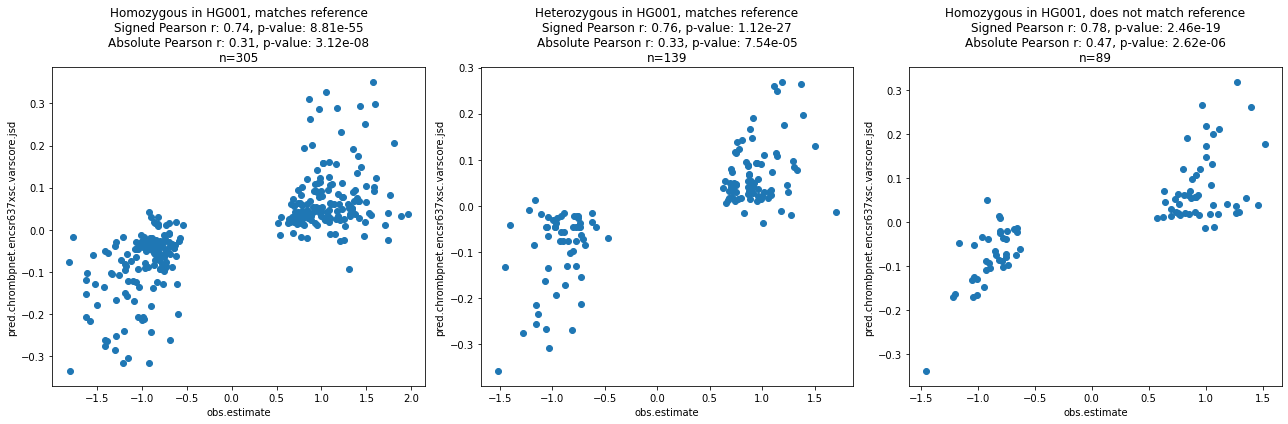

In [184]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
values = {"Homozygous match": "Homozygous in HG001, matches reference", 
        "Heterozygous match": "Heterozygous in HG001, matches reference",
        "Homozygous no match": "Homozygous in HG001, does not match reference"}
for ax, value in zip(axes, ["Homozygous match", "Heterozygous match", "Homozygous no match"]):
    dffilt = df[(df["Annotation"] == value) & df["var.isused"] & (df["obs.label"]==1)]
    
    # Calculate Pearson correlation coefficients
    pear_signed = pearsonr(dffilt["obs.estimate"], dffilt["pred.chrombpnet.encsr637xsc.varscore.jsd"])
    pear_absolute = pearsonr(abs(dffilt["obs.estimate"]), abs(dffilt["pred.chrombpnet.encsr637xsc.varscore.jsd"]))
    
    # Scatter plot
    ax.scatter(dffilt["obs.estimate"], dffilt["pred.chrombpnet.encsr637xsc.varscore.jsd"])
    
    # Title showing the Pearson correlations
    ax.set_title(
        f"{values[value]}\nSigned Pearson r: {pear_signed[0]:.2f}, p-value: {pear_signed[1]:.2e}\n"
        f"Absolute Pearson r: {pear_absolute[0]:.2f}, p-value: {pear_absolute[1]:.2e}\n"
        f"n={dffilt.shape[0]}"
    )
    
    # Set labels for each plot
    ax.set_xlabel("obs.estimate")
    ax.set_ylabel("pred.chrombpnet.encsr637xsc.varscore.jsd")

# Adjust layout
plt.tight_layout()
plt.show()

In [123]:
#sum( df["obs.label"]==1)
327+141+92

560

In [126]:
sum((df["obs.label"]==1)&(df["var.isused"]))

560

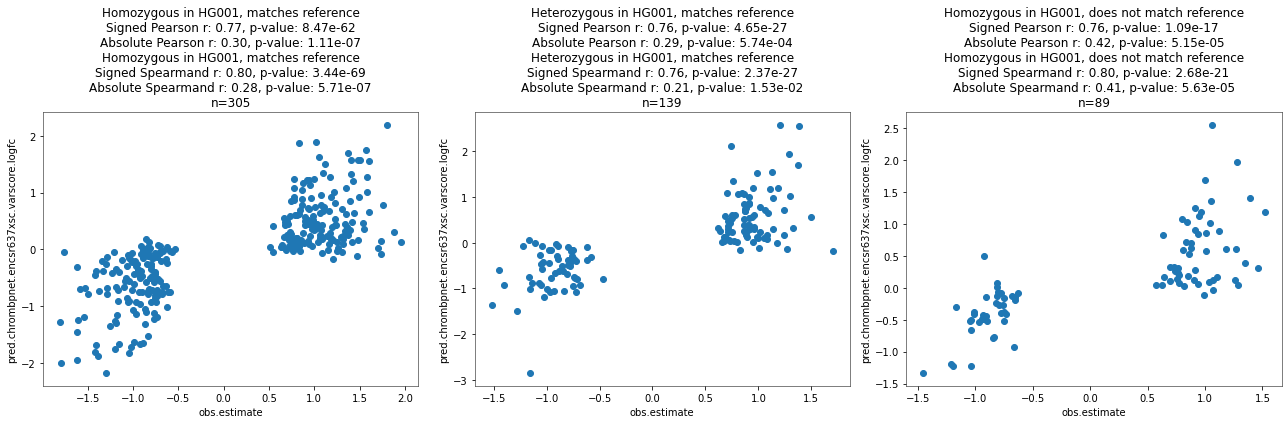

In [33]:
import matplotlib

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42 
matplotlib.rc('axes', linewidth=0.5) 

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
values = {"Homozygous match": "Homozygous in HG001, matches reference", 
        "Heterozygous match": "Heterozygous in HG001, matches reference",
        "Homozygous no match": "Homozygous in HG001, does not match reference"}
for ax, value in zip(axes, ["Homozygous match", "Heterozygous match", "Homozygous no match"]):
    dffilt = df[(df["Annotation"] == value) & df["var.isused"] & (df["obs.label"]==1)]
    
    # Calculate Pearson correlation coefficients
    pear_signed = pearsonr(dffilt["obs.estimate"], dffilt["pred.chrombpnet.encsr637xsc.varscore.logfc"])
    pear_absolute = pearsonr(abs(dffilt["obs.estimate"]), abs(dffilt["pred.chrombpnet.encsr637xsc.varscore.logfc"]))
    spear_signed = spearmanr(dffilt["obs.estimate"], dffilt["pred.chrombpnet.encsr637xsc.varscore.logfc"])
    spar_absolute = spearmanr(abs(dffilt["obs.estimate"]), abs(dffilt["pred.chrombpnet.encsr637xsc.varscore.logfc"]))
    
    # Scatter plot
    ax.scatter(dffilt["obs.estimate"], dffilt["pred.chrombpnet.encsr637xsc.varscore.logfc"], rasterized=True)
    
    # Title showing the Pearson correlations
    ax.set_title(
        f"{values[value]}\nSigned Pearson r: {pear_signed[0]:.2f}, p-value: {pear_signed[1]:.2e}\n"
        f"Absolute Pearson r: {pear_absolute[0]:.2f}, p-value: {pear_absolute[1]:.2e}\n"
        f"{values[value]}\nSigned Spearmand r: {spear_signed[0]:.2f}, p-value: {spear_signed[1]:.2e}\n"
        f"Absolute Spearmand r: {spar_absolute[0]:.2f}, p-value: {spar_absolute[1]:.2e}\n"
        f"n={dffilt.shape[0]}"
    ) 
    
    # Set labels for each plot
    ax.set_xlabel("obs.estimate")
    ax.set_ylabel("pred.chrombpnet.encsr637xsc.varscore.logfc")

# Adjust layout
plt.tight_layout()
plt.savefig("figures/dsqtls_zygosity.pdf", transparent=True, dpi=300)

#plt.show()